In [79]:
import jax.scipy as jsp
from scipy.datasets import ascent
import matplotlib as mpl

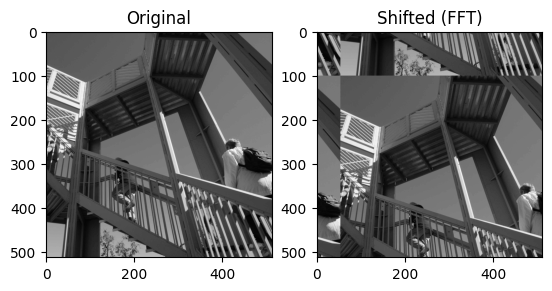

In [22]:
import jax.numpy as np
from scipy.fft import fft2, ifft2, fftshift
import matplotlib.pyplot as plt


def shift_image(img, dx, dy):
    ny, nx = img.shape
    x = np.fft.fftfreq(nx)
    y = np.fft.fftfreq(ny)
    X, Y = np.meshgrid(x, y)

    # Compute phase ramp
    phase = np.exp(-2j * np.pi * (dx * X + dy * Y))

    # Apply shift in Fourier space
    f_img = fft2(img)
    f_shifted = f_img * phase
    return np.real(ifft2(f_shifted))


img_shifted = shift_image(ascent(), dx=53, dy=101)

plt.subplot(1, 2, 1)
plt.imshow(ascent(), cmap="gray")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(img_shifted, cmap="gray")
plt.title("Shifted (FFT)")

plt.show()

Equation 13

In [26]:
def U(image):
    return np.fft.fft(image, axis=1)


def Uinv(image):
    return np.fft.ifft(image, axis=1)


def V(image):
    return np.fft.fft(image, axis=0)


def Vinv(image):
    return np.fft.ifft(image, axis=0)

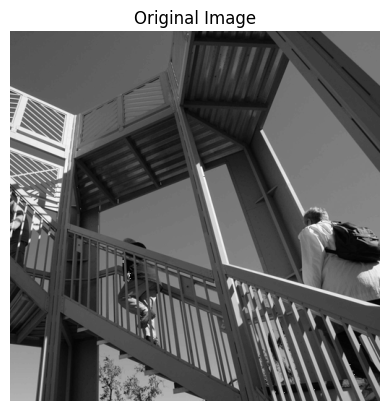

In [39]:
theta = np.deg2rad(30)  # 30 degrees in radians
a = np.tan(theta / 2)
b = -np.sin(theta)

f = ascent()

plt.imshow(f, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()


Fx = U(f)

# gx = Uinv(U(f) * np.exp(-2 * np.pi * 1j * a))

# plt.imshow(np.abs(gx), cmap="gray")
# plt.title("Shear 1")
# plt.axis("off")
# plt.show()

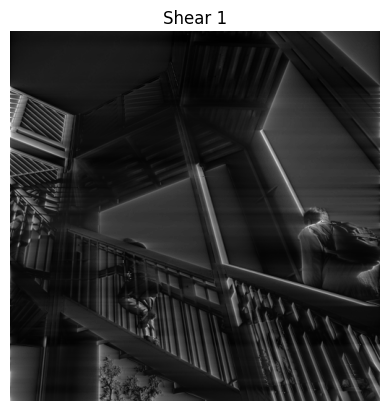

In [45]:
ramp = np.linspace(0, 1, f.shape[1])
gx = Uinv(Fx * np.exp(-2 * np.pi * 1j * a * ramp))
plt.imshow(np.abs(gx), cmap="gray")
plt.title("Shear 1")
plt.axis("off")
plt.show()

In [59]:
np.pi / 4

0.7853981633974483

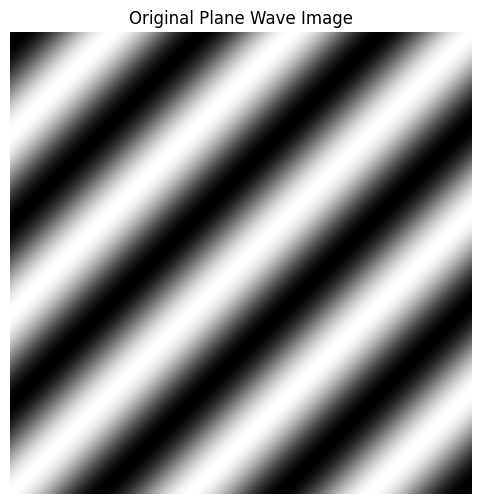

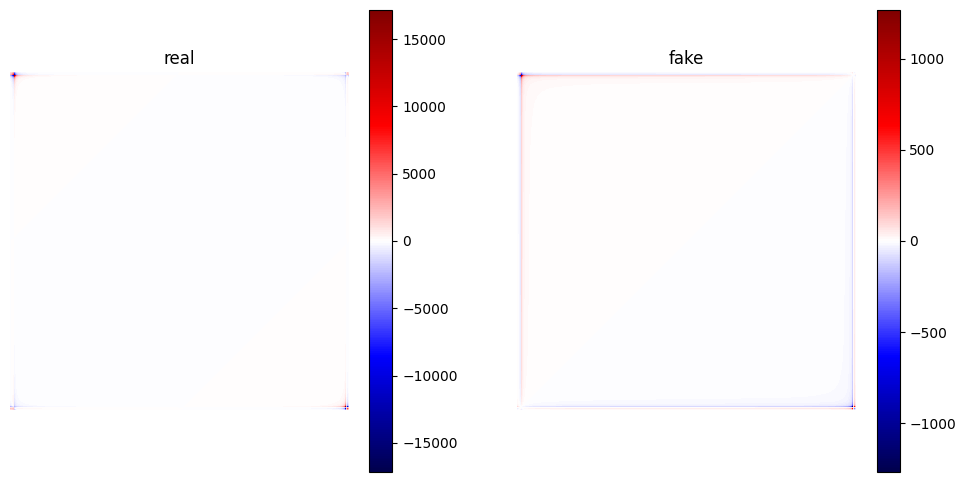

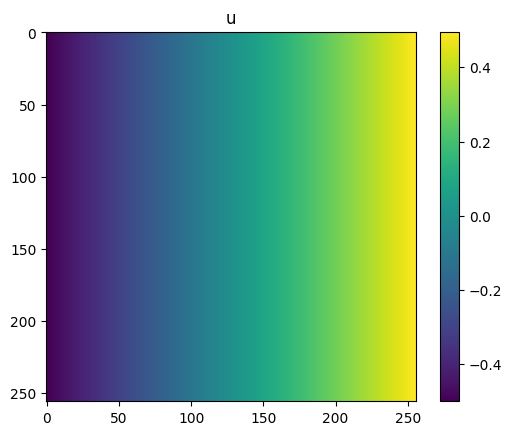

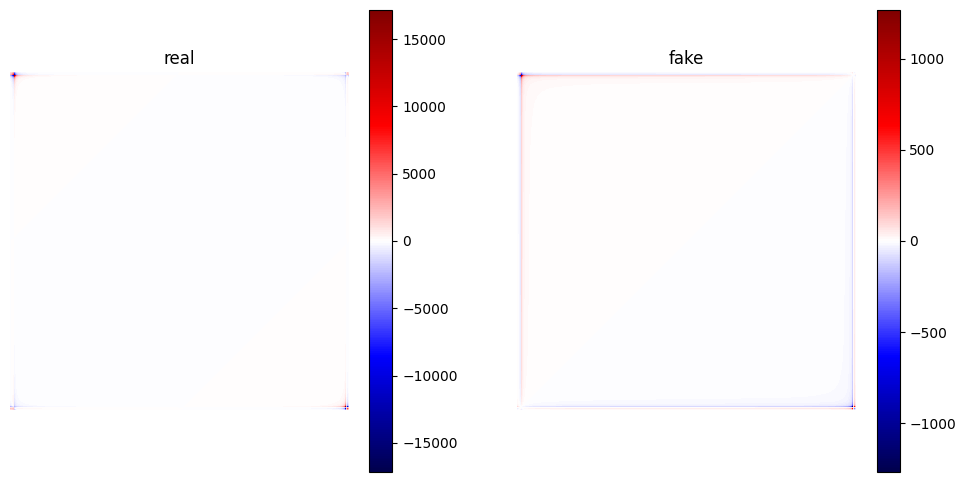

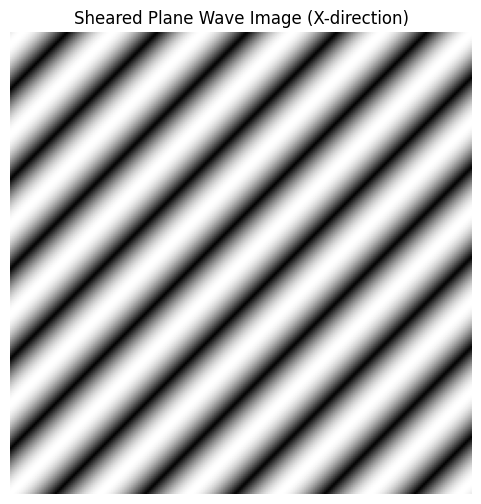

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, ifftshift


# Create a 2D plane wave
def plane_wave(size, u0=0.01, v0=0.01):
    """
    Create a 2D plane wave function.

    Parameters:
    - size: The size of the output image (height, width).
    - u0, v0: Spatial frequencies in the x and y directions.

    Returns:
    - 2D numpy array representing the plane wave.
    """
    x = np.linspace(-size[1] // 2, size[1] // 2, size[1])
    y = np.linspace(-size[0] // 2, size[0] // 2, size[0])

    X, Y = np.meshgrid(x, y)

    # Plane wave equation: cos(2π(u₀x + v₀y))
    return np.cos(2 * np.pi * (u0 * X + v0 * Y))


# Define the size of the image
image_size = (256, 256)

# Generate the plane wave image
image = plane_wave(image_size)

# Plot the original plane wave image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Original Plane Wave Image")
plt.axis("off")
plt.show()

# Compute the 2D Fourier transform of the image
F = fft2(image)

# # Shift zero-frequency component to the center
# F = fftshift(F)

# Plot the Fourier transform of the sheared plane wave
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(
    F.real,
    cmap="seismic",
    norm=mpl.colors.CenteredNorm(),
)
plt.title("real")
plt.axis("off")
plt.colorbar()

plt.subplot(122)
plt.imshow(
    F.imag,
    cmap="seismic",
    norm=mpl.colors.CenteredNorm(),
)
plt.title("fake")
plt.axis("off")
plt.colorbar()
plt.show()

# Get the shape of the image
height, width = image.shape

# Create coordinate grids for u and v (frequency components)
x = np.linspace(-width // 2, width // 2, width)
y = np.linspace(-height // 2, height // 2, height)

u = np.fft.fftshift(np.fft.fftfreq(width))
v = np.fft.fftshift(np.fft.fftfreq(height))

# Meshgrid of u and v for 2D phase shift
u, v = np.meshgrid(u, v)

plt.imshow(u)
plt.title("u")
plt.colorbar()
plt.show()

# Set shear factor (alpha)
shear_factor = 0.05  # Adjust this value for stronger/weaker shear

# Phase shift term for shear in the x-direction (depends on v, u)
phase_shift = np.exp(-2j * np.pi * np.arange(F.shape[0]))

# Apply the phase shift in the Fourier domain
F_sheared = F * phase_shift

# Plot the Fourier transform of the sheared plane wave
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(
    F_sheared.real,
    cmap="seismic",
    norm=mpl.colors.CenteredNorm(),
)
plt.title("real")
plt.axis("off")
plt.colorbar()

plt.subplot(122)
plt.imshow(
    F_sheared.imag,
    cmap="seismic",
    norm=mpl.colors.CenteredNorm(),
)
plt.title("fake")
plt.axis("off")
plt.colorbar()
plt.show()

# Shift back the zero-frequency component
F_sheared_shifted_back = ifftshift(F_sheared)

# Compute the inverse 2D Fourier transform to get the sheared image
sheared_image = np.abs(ifft2(F_sheared_shifted_back))

# Plot the sheared image
plt.figure(figsize=(6, 6))
plt.imshow(sheared_image, cmap="gray")
plt.title("Sheared Plane Wave Image (X-direction)")
plt.axis("off")
plt.show()

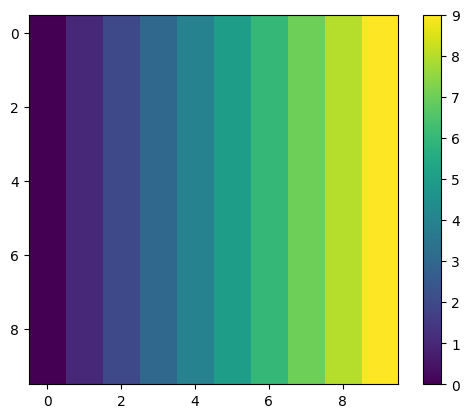

In [106]:
x = np.ones((10, 10)) * range(10)

plt.imshow(x)
plt.colorbar()
plt.show()

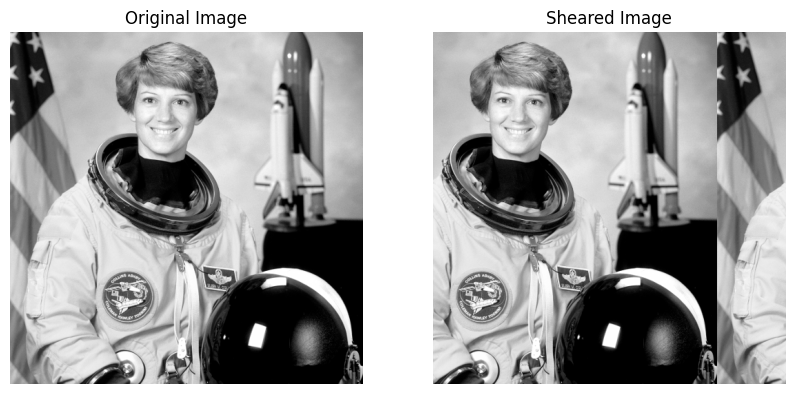

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Step 1: Generate the shear in the x-direction using FFTs
# Load the example image
image = data.astronaut()[:, :, 0]  # Using just one channel (grayscale)

# Parameters for shear
shear_amount = 0.000  # Shear amount in pixels

# Get the shape of the array
ny, nx = image.shape

# Compute the 2D Fourier transform of the image
f_image = np.fft.fftshift(np.fft.fft2(image))

# Create a frequency grid for the x-direction
kx = np.fft.fftfreq(nx)


# Apply the shear transformation in the Fourier domain
# The phase factor for shear in the x direction is exp(i * kx * shear_amount)
shear_factor = np.exp(1j * 2 * np.pi * kx * 100)

# Apply the shear factor to the Fourier-transformed image
f_image_sheared = f_image * shear_factor

# Step 2: Perform the inverse Fourier transform to get the sheared image back
sheared_image = np.fft.ifft2(np.fft.ifftshift(f_image_sheared)).real

# Step 3: Plot the original and sheared images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(sheared_image, cmap="gray")
axes[1].set_title("Sheared Image")
axes[1].axis("off")

plt.show()

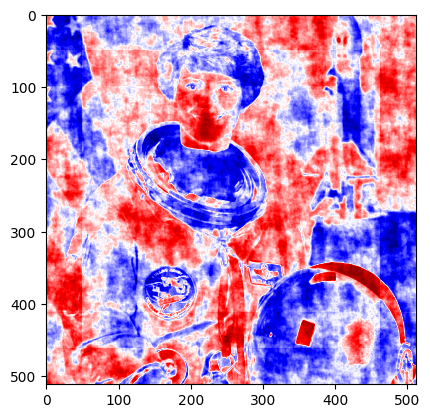

In [135]:
plt.imshow(
    image - np.abs(sheared_image), cmap="seismic", norm=mpl.colors.CenteredNorm()
)

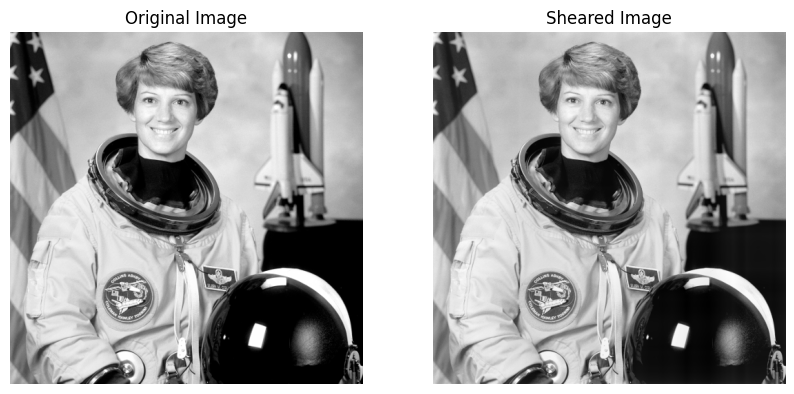

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Step 1: Generate the shear in the x-direction using FFTs
# Load the example image
image = data.astronaut()[:, :, 0]  # Using just one channel (grayscale)

# Parameters for shear
shear_amount = 0.1  # Shear amount (relative shear)

# Get the shape of the array
ny, nx = image.shape

# Compute the 2D Fourier transform of the image
f_image = np.fft.fftshift(np.fft.fft2(image))

# Create frequency grids for x and y directions
kx = np.fft.fftfreq(nx)
ky = np.fft.fftfreq(ny)

# Generate a meshgrid for kx and ky (frequency space)
KX, KY = np.meshgrid(kx, ky)

# Apply the shear transformation in the Fourier domain
# The shear factor is exp(i * 2 * pi * kx * shear_amount * ky)
shear_factor = np.exp(1j * 2 * np.pi * KX * shear_amount * KY)

# Apply the shear factor to the Fourier-transformed image
f_image_sheared = f_image * shear_factor

# Step 2: Perform the inverse Fourier transform to get the sheared image back
sheared_image = np.fft.ifft2(np.fft.ifftshift(f_image_sheared)).real

# Step 3: Plot the original and sheared images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(sheared_image, cmap="gray")
axes[1].set_title("Sheared Image")
axes[1].axis("off")

plt.show()